The first thing that I've done is to understand the dataset, how it is structured and its annotations, with all the attributes. I understand what was each attribute representing and took a look at some examples. After that I had to understand how the ground truth for the image retrieval works, i.e. annotations given by the professor. It represent a list of possible image queries with all their attributes changes and for each of them a list of all the possible correct retrieved images with that kind of search.

# Dataset setup

In [1]:
import torch
from pathlib import Path
from torchvision.datasets import CelebA

In [2]:
data_root = Path("./datasets")

In [3]:
celeba = CelebA(root=data_root, split="test", download=False)

In [4]:
print(len(celeba))

19962


## Function for visualize the image and it's attribute

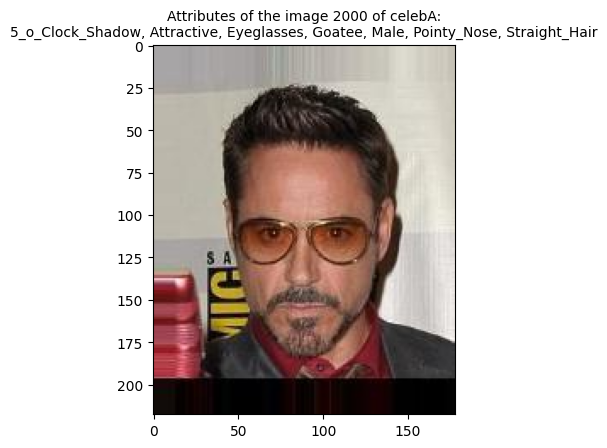

In [5]:
import matplotlib.pyplot as plt

def show_celeb_image(idx):
    img, attrs = celeba[idx]

    attr_names = (celeba.attr_names[i] for i, val in enumerate(attrs) if val == 1)

    plt.figure()
    plt.imshow(img)
    plt.title(f"Attributes of the image {idx} of celebA:\n{', '.join(attr_names)}", fontsize=10)
    plt.show()

show_celeb_image(2000)


## Metrics
Here I define the metrics for the evaluation of the retrieved images, in this case we use recall and the precision by considering the top-k retrieved images. This means that if I retrieved 10 images and select k=1, I compute the metrics as follows:
* RECALL: at least one of the top-k images hits one of the indeces in the ground truth
* PRECISION: fraction of top-k retrived images that are correctly predicted

EX:
ground truth: [1, 2, 3, 4, 5]
retrieved: [3, 2, 1]
In this case the recall will be equal to 1 because at least 1 element is correct and the precision with k = 1 will be 1 but with k = 5 will be 3/5=0.6

In [6]:
def evaluate_retrieval(
    retrieved_indices: list[int],
    ground_truth_indices: list[int],
    k: int
):
    """
    Evaluate the retrieval performance for a single source image.

    Args:
    ----
        retrieved_indices: list of image IDs predicted by the model,
            ordered by similarity (descending).
        ground_truth_indices: list of valid target IDs from the benchmark JSON.
        k: the cutoff for top-K evaluation (e.g., 1, 5, 10).

    Return:
    ------
        A dictionary containing Recall@K and Precision@K.
        RECALL: NE HA TROVATA ALMENO UNA?
        PRECISION: QUANTE NE HA PRESE SU K?

    """
    # Isolate the top K predictions - they are ordered by similarity
    top_k_retrieved = retrieved_indices[:k]

    # Calculate the intersection between predictions and ground truth
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)

    # Metrics calculations
    # Recall@K (Hit Rate): 1 if at least one match is found, 0 otherwise
    recall_at_k = 1 if num_hits > 0 else 0

    # Precision@K: Fraction of top K predictions that are correct
    precision_at_k = num_hits / k

    return {
        f"Recall@{k}": recall_at_k,
        f"Precision@{k}": precision_at_k
    }

In [7]:
# --- Example Usage ---
# Suppose the model returns these indices from most to least similar:
predictions = [1, 2, 3, 4, 5]
# And we load this from our JSON for this specific source:
ground_truth = [3, 2, 1]

# Evaluate at K=1 and K=5 and K=10 to understand how the model is performing
print("Results @ 1:", evaluate_retrieval(predictions, ground_truth, k=1))
print("Results @ 5:", evaluate_retrieval(predictions, ground_truth, k=5))

Results @ 1: {'Recall@1': 1, 'Precision@1': 1.0}
Results @ 5: {'Recall@5': 1, 'Precision@5': 0.6}


## Annotations for the evaluation


In [8]:
import json

In [9]:
annotations_path = Path("./celeba_evaluation.json")

with open(annotations_path, "r") as f:
    annotations = json.load(f)

We can test the evaluation function with the annotations. Let's simulate retrieving data for the firt image / query

In [10]:
print("Nothing retrieved:\n", evaluate_retrieval([], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved only one wrong image:\n", evaluate_retrieval([0], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved 10 correct images:\n", evaluate_retrieval(annotations[0]["ground_truth"]["13"][:10], annotations[0]["ground_truth"]["13"], 1))
print()
# [0, 1, 2, 3, 4, 325, 456, 579, 685, 763]
# This returns 0 and 0 because top-5 is set to 5, and the first 5 images
# (by highest similarity) are incorrect. We need to jump at least to top-6 here!
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 5))
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 6))

Nothing retrieved:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved only one wrong image:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved 10 correct images:
 {'Recall@1': 1, 'Precision@1': 1.0}

Retrieved 5 correct images and 5 wrong images:
 {'Recall@5': 0, 'Precision@5': 0.0}
Retrieved 5 correct images and 5 wrong images:
 {'Recall@6': 1, 'Precision@6': 0.16666666666666666}


## Import the CLIP model
Import a standard model from Hugging Face of CLIP

In [11]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

/home/disi/miniconda3/envs/dl_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device: ", device)
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
# Let's put the model in evaluation mode
model.eval()

# Deactivate the computing of the gradients
for param in model.parameters():
  param.requires_grad = False

Selected device:  cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10757.33it/s]

Now I want to extract the images of CelebA and passing them through CLIP I extract their embeddings, let's first start just with the first 500 images

In [13]:
images, attr_tens = zip(*[celeba[i] for i in range(500)])

print("Image embeddings extraction...")

# Pass all the images together to the processor
# If they are too much for the GPU, I could do mini-batch
inputs = processor(images=list(images), return_tensors="pt").to(device)

with torch.no_grad():
    # Raw output from the model
    outputs = model.get_image_features(**inputs)

    img_emb = outputs.pooler_output

    # img_emb is a torch tensor and I can normalize
    img_emb = img_emb / img_emb.norm(p=2, dim=-1, keepdim=True)

    # Move to the cpu
    image_embeddings = img_emb.cpu()

print("Final embeddings tensor: ", image_embeddings.shape)



Image embeddings extraction...


Final embeddings tensor:  torch.Size([500, 512])


Mapping the attributes of CelebA in text groups that can be given to CLIP in order to compute text embeddings

In [14]:
concepts = {
    "5_o_Clock_Shadow": [
        "a photo of a person with 5 o'clock shadow",
        "a photo of a person without 5 o'clock shadow"
    ],
    "Arched_Eyebrows": [
        "a photo of a person with arched eyebrows",
        "a photo of a person without arched eyebrows"
    ],
    "Attractive": [
        "a photo of an attractive person",
        "a photo of an unattractive person"
    ],
    "Bags_Under_Eyes": [
        "a photo of a person with bags under eyes",
        "a photo of a person without bags under eyes"
    ],
    "Bald": [
        "a photo of a bald person",
        "a photo of a person with hair"
    ],
    "Bangs": [
        "a photo of a person with bangs",
        "a photo of a person without bangs"
    ],
    "Big_Lips": [
        "a photo of a person with big lips",
        "a photo of a person with small lips"
    ],
    "Big_Nose": [
        "a photo of a person with a big nose",
        "a photo of a person with a small nose"
    ],
    "Black_Hair": [
        "a photo of a person with black hair",
        "a photo of a person without black hair"
    ],
    "Blond_Hair": [
        "a photo of a person with blond hair",
        "a photo of a person without blond hair"
    ],
    "Blurry": [
        "a blurry photo of a person",
        "a sharp photo of a person"
    ],
    "Brown_Hair": [
        "a photo of a person with brown hair",
        "a photo of a person without brown hair"
    ],
    "Bushy_Eyebrows": [
        "a photo of a person with bushy eyebrows",
        "a photo of a person with thin eyebrows"
    ],
    "Chubby": [
        "a photo of a chubby person",
        "a photo of a thin person"
    ],
    "Double_Chin": [
        "a photo of a person with a double chin",
        "a photo of a person without a double chin"
    ],
    "Eyeglasses": [
        "a photo of a person wearing eyeglasses",
        "a photo of a person without eyeglasses"
    ],
    "Goatee": [
        "a photo of a person with a goatee",
        "a photo of a person without a goatee"
    ],
    "Gray_Hair": [
        "a photo of a person with gray hair",
        "a photo of a person without gray hair"
    ],
    "Heavy_Makeup": [
        "a photo of a person with heavy makeup",
        "a photo of a person with no makeup"
    ],
    "High_Cheekbones": [
        "a photo of a person with high cheekbones",
        "a photo of a person without high cheekbones"
    ],
    "Male": [
        "a photo of a male person",
        "a photo of a female person"
    ],
    "Mouth_Slightly_Open": [
        "a photo of a person with mouth slightly open",
        "a photo of a person with mouth closed"
    ],
    "Mustache": [
        "a photo of a person with a mustache",
        "a photo of a person without a mustache"
    ],
    "Narrow_Eyes": [
        "a photo of a person with narrow eyes",
        "a photo of a person with wide eyes"
    ],
    "No_Beard": [
        "a photo of a person with no beard",
        "a photo of a person with a beard"
    ],
    "Oval_Face": [
        "a photo of a person with an oval face",
        "a photo of a person without an oval face"
    ],
    "Pale_Skin": [
        "a photo of a person with pale skin",
        "a photo of a person without pale skin"
    ],
    "Pointy_Nose": [
        "a photo of a person with a pointy nose",
        "a photo of a person without a pointy nose"
    ],
    "Receding_Hairline": [
        "a photo of a person with a receding hairline",
        "a photo of a person without a receding hairline"
    ],
    "Rosy_Cheeks": [
        "a photo of a person with rosy cheeks",
        "a photo of a person without rosy cheeks"
    ],
    "Sideburns": [
        "a photo of a person with sideburns",
        "a photo of a person without sideburns"
    ],
    "Smiling": [
        "a photo of a smiling person",
        "a photo of a person not smiling"
    ],
    "Straight_Hair": [
        "a photo of a person with straight hair",
        "a photo of a person without straight hair"
    ],
    "Wavy_Hair": [
        "a photo of a person with wavy hair",
        "a photo of a person without wavy hair"
    ],
    "Wearing_Earrings": [
        "a photo of a person wearing earrings",
        "a photo of a person not wearing earrings"
    ],
    "Wearing_Hat": [
        "a photo of a person wearing a hat",
        "a photo of a person not wearing a hat"
    ],
    "Wearing_Lipstick": [
        "a photo of a person wearing lipstick",
        "a photo of a person not wearing lipstick"
    ],
    "Wearing_Necklace": [
        "a photo of a person wearing a necklace",
        "a photo of a person not wearing a necklace"
    ],
    "Wearing_Necktie": [
        "a photo of a person wearing a necktie",
        "a photo of a person not wearing a necktie"
    ],
    "Young": [
        "a photo of a young person",
        "a photo of an old person"
    ]
}

Now, if I want to make a conditional retrieval I need to pass the concepts to the encoder of CLIP, that will give me text embeddings.

For the next step, I can use SVD in order to find the direction of the choosen attribute.

If for instance the user says: "I want a similar image to this Query but it must wear a hat (Wearing_Hat)"
Thus, I can take the matrix [2x512] that defines the attribute Wearing_Hat, I extract the vector that represent the direction of Waring_Hat in the CLIP space and then I create the Conditional Projection Matrix ($P_c$)

And as last step, I use this matrix to filter my database of CelebA

Now I extract text embeddings from the concepts

In [15]:
print("Text embeddings extraction...")

# Create a list with all the phrases of all the attributes
all_phrases = []
ordered_attributes = list(concepts.keys())

for attr in ordered_attributes:
  # Add both the positive and negative phrase (flat list)
  all_phrases.extend(concepts[attr])

print(f"Phrases that should be elaborated: {len(all_phrases)}")

# Tokenization and embedding extraction
inputs = processor(text=all_phrases, padding=True, return_tensors="pt").to(device)

with torch.no_grad():
  outputs = model.get_text_features(**inputs)
  text_emb = outputs.pooler_output

  # Normalize
  text_emb = text_emb / text_emb.norm(p=2, dim=-1, keepdim=True)
  all_text_embeddings = text_emb.cpu()

# Now all_text_embeddings has shape [80, 512], I want it to be [40, 2, 512]
num_attr = len(ordered_attributes)
embedding_dim = all_text_embeddings.shape[-1]

all_text_embeddings = all_text_embeddings.view(num_attr, 2, embedding_dim)
print("Shape of the final text embeddings", all_text_embeddings.shape)


Text embeddings extraction...
Phrases that should be elaborated: 80
Shape of the final text embeddings torch.Size([40, 2, 512])


Now I compute the global similarity between all the images and all the attributes, in order to see with which attribute each image is related. We can use matmul (classic matrix multiplication).

Predictions shape: torch.Size([500, 40])
----------
Attributes that the image 0 has based on similarity: 
Arched_Eyebrows
Bags_Under_Eyes
Black_Hair
Blond_Hair
High_Cheekbones
Mouth_Slightly_Open
No_Beard
Oval_Face
Smiling
Wearing_Hat
Young


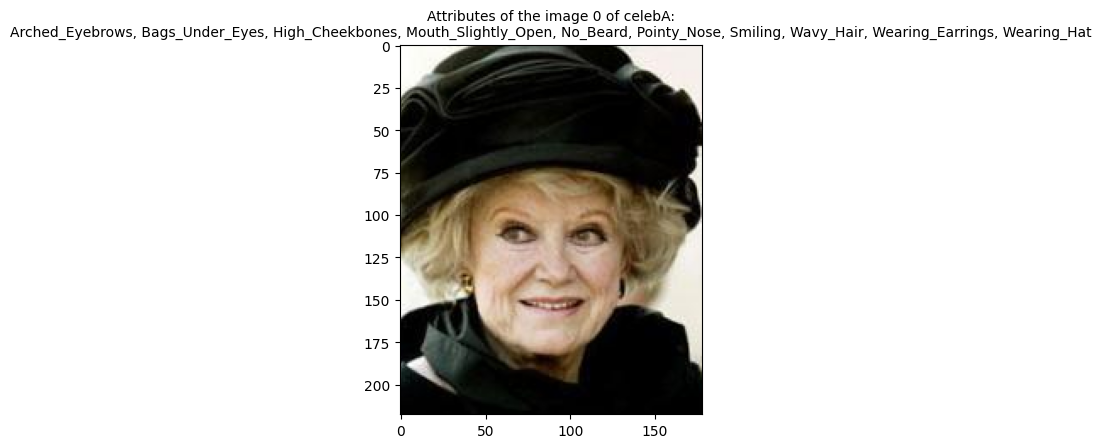

In [16]:
# We go back to [80, 512] text_embeddings shape temporarly
flatten_text = all_text_embeddings.view(-1, embedding_dim)

sim_flat = image_embeddings @ flatten_text.T

# Original shape
similarity = sim_flat.view(image_embeddings.shape[0], num_attr, 2)
similarity.shape


# Find index (0 or 1) with highest similarity of each attribute of each image
predictions = similarity.argmax(dim=-1)
print("Predictions shape:", predictions.shape) # Output: [500, 40]

# Example: let's control the k-th image
k = 0
first_image_preds = predictions[k] # Tensore di 40 elementi con valori 0 o 1

print('-'*10)
print(f"Attributes that the image {k} has based on similarity: ")

for idx, attr_name in enumerate(ordered_attributes):
    is_present = first_image_preds[idx].item() == 0 # 0 means "with"
    if is_present:
      print(attr_name)

show_celeb_image(k)

Now I would like to know how clip is performing, for each attribute I want to know how many times it predict correctly if the attributes is present or not for each image.

In [17]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Stack all the original attributes in a single tensor
real_attributes = torch.stack(attr_tens)

# CLIP returns 0 for "PRESENT ATTRIBUTE" and 1 for "ABSENT ATTRIBUTE"
# In order to be like the real attributes we need to reverse them
clip_predictions_binary = (predictions == 0).int().cpu().numpy()

# Compute metrics for each attribute
accuracy = []

for idx, attr_name in enumerate(ordered_attributes):
  # They give a tensor with 0 and 1 where idx-th attribute is present
  # or not for each image
  y_true = real_attributes[:, idx]
  y_pred = clip_predictions_binary[:, idx]

  acc = accuracy_score(y_true, y_pred)
  accuracy.append(acc)

  print(f"{attr_name:<25} | {acc*100:>16.2f}%")

print()
print("The average accuracy is: ", np.mean(accuracy))



5_o_Clock_Shadow          |            45.20%
Arched_Eyebrows           |            69.80%
Attractive                |            51.40%
Bags_Under_Eyes           |            41.20%
Bald                      |            96.00%
Bangs                     |            86.40%
Big_Lips                  |            64.40%
Big_Nose                  |            73.00%
Black_Hair                |            76.60%
Blond_Hair                |            85.80%
Blurry                    |            73.40%
Brown_Hair                |            45.60%
Bushy_Eyebrows            |            78.00%
Chubby                    |            56.80%
Double_Chin               |            63.60%
Eyeglasses                |            96.60%
Goatee                    |            63.20%
Gray_Hair                 |            92.40%
Heavy_Makeup              |            66.00%
High_Cheekbones           |            56.60%
Male                      |            99.00%
Mouth_Slightly_Open       |       

As we can see, CLIP is not performing very well, for certain attributes like 'Bald', 'Eyeglasses', 'Male' and other it has high accuracy, but for others like 'Bags_Under_Eyes', 'Heavy_Makeup' and 'Attractive' accuracy is very low. This is due to the fact that the first are geometrical and well defined concepts, attributes that the model has seen many times, while the others are not well defined, what's the definition of attractive?

Another reason could be that CLIP elaborates images resizing them into low resolution images, hence the attributes that are bigger can be easily understood (like 'Bald') and smaller once, like 'Bags_Under_Eyes' are critical.

Since the concept we defined starting from the attributes differ just by some few words one to each other ("a photo of a person with bushy eyebrows" and "a photo of a person with thin eyebrows") could happen that if the visual encoder is not too sure about the attribute and the difference between the two text embedding is not so clear, CLIP will guess.

## UPGRADE:
In order to improve the perofmance of finding these attributes in the images, I try to implement a Classification Head that will use the extract embeddings of CLIP to learn to map the embeddings into the attributes labels. In this way the network will undrestand, given that embedding vector, which attribute is more likely that image to have.


First, I implement a function to extract embeddings from images that can save them into a local file, in this way it is not necessary to recompute them everytime, since it is too excpensive

In [18]:
from tqdm import tqdm
import os

def extract_embeddings(dataset, processor, model, save_path, batch_size=64, max_images=None, device="cuda"):
  """
  This function will extract embeddings from the dataset through mini-batch
  and save it in .pt locally

  dataset: dataset of CelebA
  processor: CLIP processor
  model: CLIP
  save_path: path where we want to save the embeddings
  batch_size: images to be processed in GPU at each step
  max_images: it will end after that number of images processed
  """

  model = model.to(device)
  model.eval()

  total_images = len(dataset) if max_images == None else min(max_images, len(dataset))

  all_img_embeddings = []
  all_attributes = []

  print(f"Beginning of {total_images} embedding extraction with batch size: {batch_size}")

  for i in tqdm(range(0, total_images, batch_size)):
    # Select the current mini-batch
    batch_end = min(i + batch_size, total_images)
    batch_data = [dataset[j] for j in range(i, batch_end)]

    # Divide images from attributes in current batch
    batch_images, batch_attr = zip(*batch_data)

    # Pass through the GPU
    inputs = processor(images=list(batch_images), return_tensors="pt").to(device)

    with torch.no_grad():
      # Exctract features
      outputs = model.get_image_features(**inputs)
      if hasattr(outputs, 'pooler_output'):
        img_emb = outputs.pooler_output
      else:
        img_emb = outputs

      # Normalize
      img_emb = img_emb / img_emb.norm(p=2, dim=-1, keepdim=True)

      # Move results on the CPU
      all_img_embeddings.append(img_emb.cpu())

      # Stack in a single tensor
      batch_attr_tensor = torch.stack(batch_attr) if isinstance(batch_attr[0], torch.Tensor) else torch.tensor(batch_attr)
      all_attributes.append(batch_attr_tensor.cpu())

  # merge all the mini-batch in one single final tensor
  final_embeddings = torch.cat(all_img_embeddings, dim = 0)
  final_attributes = torch.cat(all_attributes, dim = 0)

  # Local save of the embeddings
  data_to_save = {
      "image_embeddings": final_embeddings,
      "labels": final_attributes
  }

  torch.save(data_to_save, save_path)
  print(f"\nExtraction completed!")
  print(f"Embedding saved in: {os.path.abspath(save_path)}")
  print(f"Final embedding shape: {final_embeddings.shape}")
  print(f"Final attributes shape: {final_attributes.shape}")

Save the embeddings locally in .pt format

In [19]:
FILE_NAME = "./celeba_image_embeddings.pt"
EXTRACTION = False

if EXTRACTION:
  extract_embeddings(dataset=celeba, processor=processor, model=model, save_path=FILE_NAME, batch_size=64, max_images=None, device=device)
else:
  print(f"File already extracted in {FILE_NAME}")

File already extracted in ./celeba_image_embeddings.pt


In [20]:
# Reload the data
data_reload = torch.load("./celeba_image_embeddings.pt")

# Extract the image embeddings and the attributes
image_embeddings = data_reload["image_embeddings"]
attr_tens = data_reload["labels"]

print("Data reloaded correctly!")
print("Image embeddings:", image_embeddings.shape)
print("Attributes:", attr_tens.shape)


Data reloaded correctly!
Image embeddings: torch.Size([19962, 512])
Attributes: torch.Size([19962, 40])


## CREATE DATASET   
Create a dataset for the embeddings anf ro the real attribute labels of celebA

In [21]:
from torch.utils.data import Dataset, DataLoader


class EmbeddingDataset(Dataset):
  def __init__(self, image_embeddings, real_attributes):
    """
    image_embeddings: tensor [N, 512]
    real_attributes: tensor or tuple [N, 40] (with 0 and 1)
    """

    self.X = image_embeddings.float()

    if isinstance(real_attributes, tuple):
      real_attributes = torch.stack(real_attributes)
    self.Y = real_attributes.float()


  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]

## ARCHITECTURE
Classification Head: since each image can have more than one attribute (multi-label classification) I usa a linear layer neural network

In [22]:
import torch.nn as nn

class CelebAHead(nn.Module):
  def __init__(self, input_dim=512, num_classes=40):
    super().__init__()

    # Single layer
    self.classifier = nn.Linear(input_dim, num_classes)


  def forward(self, x):
    return self.classifier(x)

### TRAIN AND VALIDATION FUNCTION
In this function we will manage the training loop for the multi-label classification using the BCEWithLogitsLoss (Binary Cross Entropy with embedded Sigmoid)

In [ ]:
import torch.optim as optim

def train_model(model, train_loader, epochs=20, lr=0.001, device="cuda"):
  model = model.to(device)

  # Loss function - criterion
  criterion = nn.BCEWithLogitsLoss()

  # Optimizer - Adam
  optimizer = optim.Adam(model.parameters(), lr=lr)

  # Start the training
  print(f"Start training on {device}")
  for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_Y in train_loader:
      batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

      # Gradients reset
      optimizer.zero_grad()

      # Forward pass
      outputs = model(batch_X)
      loss = criterion(outputs, batch_Y.float())

      # Backpropagation
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch+1)%4 == 0:
      print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}")

  print("Training completed!")
  return model


## ARCHITECTURE
Classification Head: since each image can have more than one attribute (multi-label classification) I usa a linear layer neural network

In [24]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, dataset, ordered_attributes, device="cuda"):
  model.eval()
  model = model.to(device)

  # Exctract all the data from the dataset for the evaluation
  if isinstance(dataset, torch.utils.data.Subset):
    all_X = dataset.dataset.X[dataset.indices].to(device)
    all_Y_true = dataset.dataset.Y[dataset.indices].numpy()
  else:
    all_X = dataset.X.to(device)
    all_Y_true = dataset.Y.numpy()

  with torch.no_grad():
    logits = model(all_X)
    probabilities = torch.sigmoid(logits).cpu().numpy()

    # Threshold of 0.5, if higher attribute is present, otherwise it is not
    predictions = (probabilities >= 0.5).astype(int)

    # Compute the accuracy for each attribute
    print(f"\n{'Attribute':<25} | {'Accuracy with Head':<25}")
    print("-"*50)

    accuracy = []

    for idx, attr_name in enumerate(ordered_attributes):
      acc = accuracy_score(all_Y_true[:, idx], predictions[:, idx])
      print(f"{attr_name:<25} | {acc*100:>20.2f}%")
      accuracy.append(acc)
    print("Average accuracy: ", np.mean(accuracy)*100)

### LET'S TRAIN AND EVALUATE

In [73]:
from torch.utils.data import random_split

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.01

# Prepare the data
full_dataset = EmbeddingDataset(image_embeddings, attr_tens)

# Split train and test data
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print("Images for training: ", train_size)
print("Images for testing: ", test_size)

# DataLoader only for the training set
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


# Initialize the model
model_head = CelebAHead(input_dim=512, num_classes=40)

# Training
model_head = train_model(
    model=model_head,
    train_loader=train_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE
)

# Evaluation
evaluate_model(model_head, test_dataset, ordered_attributes, device=DEVICE)

Images for training:  15969
Images for testing:  3993
Start training on cuda
Epoch [4/20] - Loss: 0.2067
Epoch [8/20] - Loss: 0.2013
Epoch [12/20] - Loss: 0.1988
Epoch [16/20] - Loss: 0.1972
Epoch [20/20] - Loss: 0.1962
Training completed!

Attribute                 | Accuracy with Head       
--------------------------------------------------
5_o_Clock_Shadow          |                93.29%
Arched_Eyebrows           |                82.27%
Attractive                |                83.52%
Bags_Under_Eyes           |                83.72%
Bald                      |                98.90%
Bangs                     |                95.49%
Big_Lips                  |                73.28%
Big_Nose                  |                84.92%
Black_Hair                |                87.83%
Blond_Hair                |                94.77%
Blurry                    |                95.49%
Brown_Hair                |                87.60%
Bushy_Eyebrows            |                91.49%
Chub

Now the results has changed, when we tried to infer if a image has that attribute using just the cosine similarity between text embeddings and image embeddings, we got a bad average accuracy on the attributes (72%), because we trusted only on the capacity of CLIP to understand the natural language and the details in the images, in Zero-Shot mode. If we use the classification head the Linear Layer will take the image embedding vector and will understand the best mathematics combination within that numbers that describes that specific attribute (or more than one). As a result of the classification head we improved the accuracy of this test, reaching an accuracy of 90.8%.

# RANDOM BASELINE RETRIEVAL
In order to make a comparison, I initially try to retrieve images by simply take random images from celeba, I expect it to perform really bad.

In [26]:
import numpy as np
import torch

def random_baseline_retrieval(database_embeddings, id_query, top_k=5):
    """
    Simulates a completely random retrieval by extracting K images from the database,
    """
    total_images = database_embeddings.shape[0]
    
    # Generate a random permutation of all indices in the database
    possible_indices = np.arange(total_images)
    
    possible_indices = possible_indices[possible_indices != id_query]
    
    # Select K indeces
    random_retrieved = np.random.choice(possible_indices, size=top_k, replace=False)

    return random_retrieved.tolist()

def evaluate_random_baseline(k_val=5):
    """
    Executes the random retrieval for all annotations to compute the baseline.
    """
    random_rec_hist = []
    random_prec_hist = []
    
    # Cycle on all the queries
    for n in range(13):
        id_images = list(annotations[n]["ground_truth"].keys())
        
        # Cycle on all the images associated with that query
        for id_img_str in id_images:
            id_query = int(id_img_str)
            ground_truth_indeces = annotations[n]["ground_truth"][id_img_str]
            
            retrieved_indeces = random_baseline_retrieval(
                database_embeddings=image_embeddings, 
                id_query=id_query, 
                top_k=k_val
            )
            
            res = evaluate_retrieval(retrieved_indeces, ground_truth_indeces, k=k_val)
            random_rec_hist.append(res[f'Recall@{k_val}'])
            random_prec_hist.append(res[f'Precision@{k_val}'])
            
    return np.mean(random_rec_hist), np.mean(random_prec_hist)


k_parameter = 5
rand_recall, rand_precision = evaluate_random_baseline(k_val=k_parameter)

print("=== RANDOM BASELINE RESULTS ===")
print(f"Random Recall@{k_parameter}:    {rand_recall:.6f}")
print(f"Random Precision@{k_parameter}: {rand_precision:.6f}")

=== RANDOM BASELINE RESULTS ===
Random Recall@5:    0.006663
Random Precision@5: 0.001339


The average recall (AR) is around 0.6%, which is, how we have expected, very small, because it means that only 0.6% of the time it retrieves at least one correct image in the five retrieved.

# NAÏVE LATENT SPACE ARITHMETIC 
Let's try to implement something more sophisticated, as suggested in the project assignment, I can try to implement a simple baseline using the unmodified CLIP model, in this setup we perform naïve latent space arithmetic and I will use it as lower-bound performance metric.



Define the `conditioned_query` by simply taking a linear combination of the image query and the new attribute query. In this case we will use a parameters `alpha` used to weight the influence of the text embedding. 

`conditioned_query = query_image + alpha * attr_emb` 

In [28]:
def lin_comb_conditioned_retrieval(query_img_emb, id_query, database_embeddings, selected_attributes, text_embeddings_dict, top_k=5, alpha=0.3, device="cpu"):
  """
  Apply a linear combination of image and new attribute to find image similar to the query
  conditioned by the presence of some other attributes

  query_img_emb: initial query image
  data_base_embeddings: whole database of images where to search
  selected_attributes: string list, ["Smiling", "Bangs"]
  text_embeddings_dict: contains the text concepts of the attributes
  """

  # Bidimensional and normalized embeddings
  if query_img_emb.ndim == 1:
    query_img_emb = query_img_emb.unsqueeze(0)

  query_img_emb = query_img_emb / query_img_emb.norm(p=2, dim=-1, keepdim=True)
  database_embeddings = database_embeddings / database_embeddings.norm(p=2, dim=-1, keepdim=True)

  # Build the matrix C
  # Gather the positive text concepts of the attributes of CelebA
  cond_vector = []
  for attr in selected_attributes:
    pos_text_emb = text_embeddings_dict[attr][0]
    pos_text_emb = pos_text_emb / pos_text_emb.norm(p=2, dim=-1)
    cond_vector.append(pos_text_emb)

  # Mean of the conditioning vectors
  conditioning_vector = torch.stack(cond_vector).mean(dim=0).to(device)
  conditioning_vector = conditioning_vector / conditioning_vector.norm(p=2, dim=-1)

  conditioned_query = query_img_emb.to(device) + alpha * conditioning_vector
  conditioned_query = conditioned_query / conditioned_query.norm(p=2, dim=-1, keepdim=True)

  # Compute the conditional similarity
  similarities = torch.mm(conditioned_query, database_embeddings.to(device).T).squeeze(0)

  # Extract top k results
  top_scores, top_indeces = torch.topk(similarities, k=top_k)

  return top_indeces.cpu().tolist(), top_scores.cpu().tolist()


In [29]:
# I need to restore the dictionar instead of a tensor for the text embeddings
text_embeddings_dict = {}

for idx, attr_name in enumerate(ordered_attributes):
  pos_idx = 2 * idx
  neg_idx = 2 * idx + 1

  pos_vector = text_emb[pos_idx]
  neg_vector = text_emb[neg_idx]

  text_embeddings_dict[attr_name] = torch.stack([pos_vector, neg_vector])

print("Each attribute format (e.g. 'Smiling'):", text_embeddings_dict["Smiling"].shape)

Each attribute format (e.g. 'Smiling'): torch.Size([2, 512])


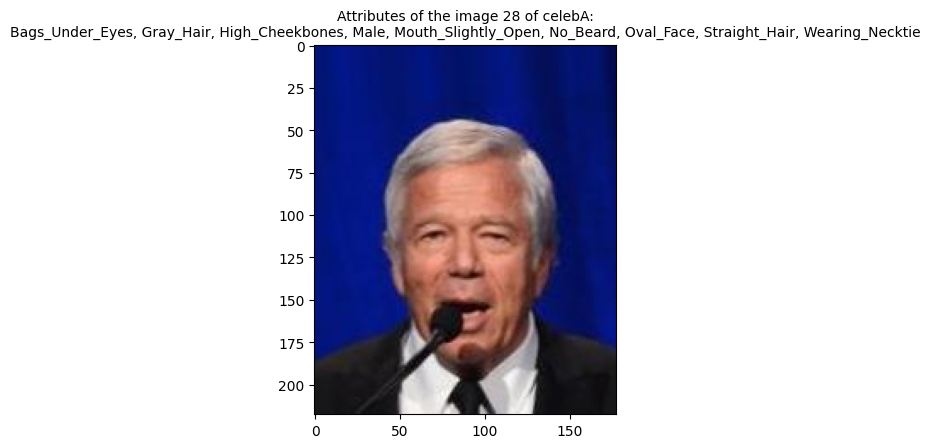

[0.38551777601242065, 0.3840845823287964, 0.37830185890197754, 0.3779827356338501, 0.3778502345085144]

[8486, 10282, 14528, 12958, 12896]


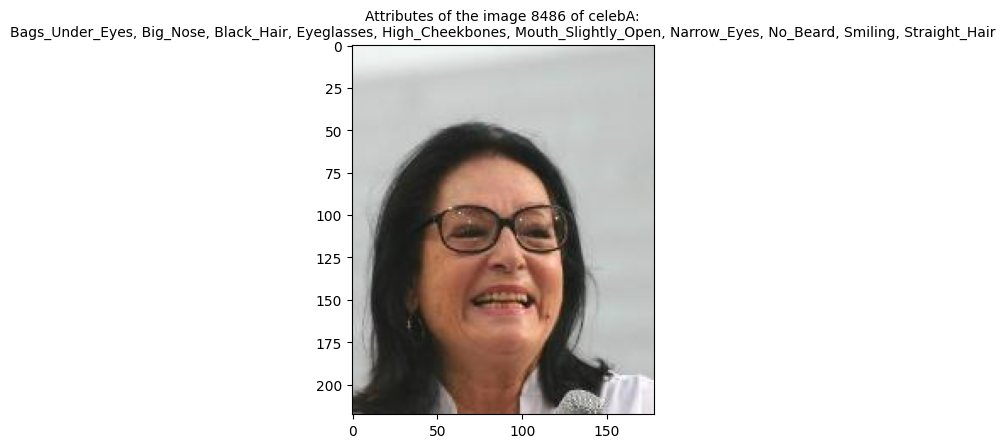

In [30]:
id_query = 28
show_celeb_image(id_query)
query_emb = image_embeddings[id_query]

new_attributes = ["Smiling", "Eyeglasses"]

res_ind, score = lin_comb_conditioned_retrieval(
    query_img_emb=query_emb,
    id_query=id_query,
    database_embeddings=image_embeddings,
    selected_attributes=new_attributes,
    text_embeddings_dict=text_embeddings_dict,
    alpha=6,
    top_k=5
)

print(score)
print()
print(res_ind)

show_celeb_image(res_ind[0])

I can already see that the result is not very good, it also depend on the weight of alpha that is weighting the decision based on the query image or on the attributes requirement. If the weight is too small the image is influencing too much the decision and even though I try to change attribute it returns always the same image, in practice it returns the closest neighbour to the image query in the CLIP space. Probably this bad results are also given by the fact that in order to define the `conditioning_vector` of the attributes I simply take the mean of the new attributes embeddings. 

Now, this function is only considering "adding attributes" and not "removing attributes", I want to implement a function that can take, as the assignment requests, both an addition and a subtraction of attributes in the image query.

In order to do so, instead of only adding the new attribute embeddings to the final `conditioned_query` I can subtract the attribute that should be removed.

`conditioned_query = query_image + alpha * pos_attr_emb - alpha * neg_attr_emb` 


In [31]:
def lin_comb_mixed_cond_retrieval(query_img_emb, id_query, database_embeddings, attributes, text_embeddings_dict, top_k=5, alpha=0.3, device="cpu"):
  """
  Apply conditioned retrieval in order to find images similar to the query
  but adding and/or removing some attributes

  attributes: string list e.g. ["+Smiling", "-Eyelgasses"]
  """

  # I need bidimensional and normalized embeddings
  if query_img_emb.dim() == 1:
    query_img_emb = query_img_emb.unsqueeze(0)

  query_img_emb = query_img_emb / query_img_emb.norm(p=2, dim=-1, keepdim=True)
  database_embeddings = database_embeddings / database_embeddings.norm(p=2, dim=-1, keepdim=True)



  # Extracting the positive and negative attributes from attributes
  positive_attributes = [attr[1:] for attr in attributes if attr.startswith('+')]
  negative_attributes = [attr[1:] for attr in attributes if attr.startswith('-')]


  # Compute vector for positive attributes
  pos_vector = []
  for attr in positive_attributes:
    pos_text_emb = text_embeddings_dict[attr][0]
    pos_text_emb = pos_text_emb / pos_text_emb.norm(p=2, dim=-1)
    pos_vector.append(pos_text_emb)

  if len(pos_vector) > 0:
    pos_conditioning = torch.stack(pos_vector).mean(dim=0).to(device)
    pos_conditioning = pos_conditioning / pos_conditioning.norm(p=2, dim=-1)
  else:
    pos_conditioning = torch.zeros_like(query_img_emb).squeeze(0).to(device)

  # Compute vector for negative attributes
  neg_vector = []
  for attr in negative_attributes:
    neg_text_emb = text_embeddings_dict[attr][0]
    neg_text_emb = neg_text_emb / neg_text_emb.norm(p=2, dim=-1)
    neg_vector.append(neg_text_emb)

  if len(neg_vector) > 0:
    neg_conditioning = torch.stack(neg_vector).mean(dim=0).to(device)
    neg_conditioning = neg_conditioning / neg_conditioning.norm(p=2, dim=-1)
  else:
    neg_conditioning = torch.zeros_like(query_img_emb).squeeze(0).to(device)


  # Now I need to modify the query considering also the attributes
  conditioned_query = query_img_emb.to(device) + alpha * pos_conditioning - alpha * neg_conditioning
  conditioned_query = conditioned_query / conditioned_query.norm(p=2, dim=-1, keepdim=True)


  # Compute the conditional similarity
  similarities = torch.matmul(database_embeddings.to(device), conditioned_query.T).squeeze(-1)
  similarities[id_query] = -1

  # Extract top k results
  top_scores, top_indeces = torch.topk(similarities, k=top_k)

  return top_indeces.cpu().tolist(), top_scores.cpu().tolist()



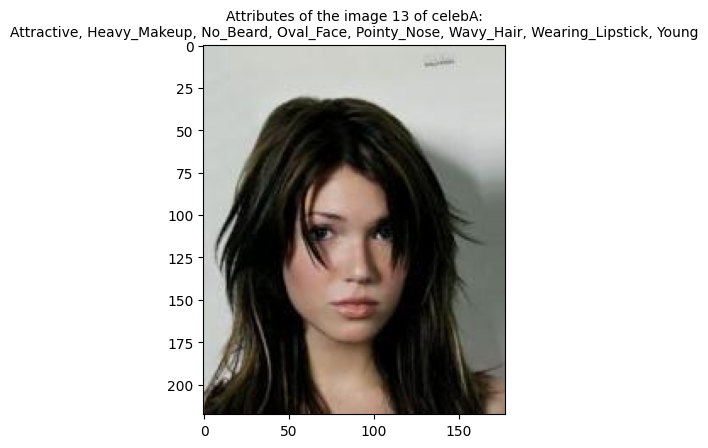

[0.43189480900764465, 0.4243099093437195, 0.4221894145011902, 0.4215465784072876, 0.42009085416793823]

[9619, 1591, 10996, 7177, 11142]


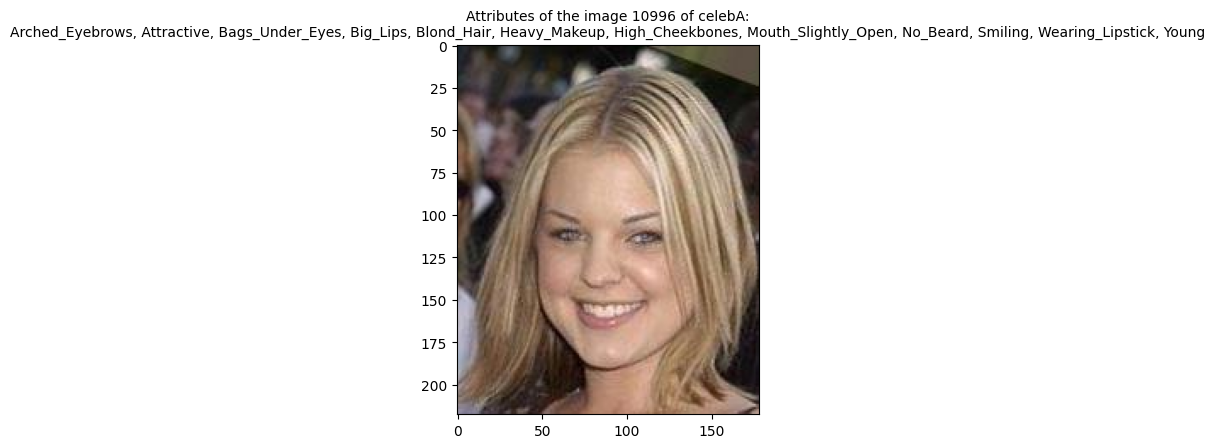

In [32]:
id_query = 13
show_celeb_image(id_query)
query_emb = image_embeddings[id_query]

new_attributes = ["+Smiling", "+Blond_Hair"]

res_ind, score = lin_comb_mixed_cond_retrieval(
    query_img_emb=query_emb,
    id_query=id_query,
    database_embeddings=image_embeddings,
    attributes=new_attributes,
    text_embeddings_dict=text_embeddings_dict,
    alpha=5,
    top_k=5
)



print(score)
print()
print(res_ind)

show_celeb_image(res_ind[2])

Now that I can choose what attribute to add and/or to remove I want to test the performance of the retrieval, by using the predefined metrics.

In order to see how retrieval is performing, we have `annotations` that is a list of index images with their "right retrieved index images" for every kind of text query we need to test.

Here is how the list is structured:

`annotations[0]["ground_truth"].keys()`

are the starting query images given the first text query `"+Smiling"`

`annotations[0]["ground_truth"]['13']`

are all the "right" retrieved images using as query the 13th image


In [33]:
print(list(annotations[0]["ground_truth"].keys())[0])
print(annotations[0]["ground_truth"]['13'])

print(annotations[10]['query'])

13
[325, 456, 579, 685, 763, 893, 981, 1363, 1646, 2142, 2747, 2812, 2979, 3318, 3325, 3536, 3637, 3932, 4361, 4452, 4549, 4569, 4678, 4780, 4831, 5112, 5208, 5448, 5533, 5926, 6127, 6153, 7595, 7798, 8151, 8342, 8440, 8592, 9009, 9452, 9506, 9612, 9685, 9881, 9930, 9968, 10367, 10719, 10915, 10968, 10973, 11813, 12361, 12673, 12695, 12788, 12934, 12986, 13060, 13141, 13731, 14215, 14323, 14848, 15058, 15422, 15953, 17205, 17384, 17638, 17748, 18096, 18202, 18221, 18290, 18446, 18503, 18799, 19046, 19179, 19800]
-Male, -Mustache


We can try to evaluate the performance of this retrieval method by changing value of alpha, that is ruling the weight for the computation of the final conditional vector. As we can see, the best performance is with alpha is around 2.5, achieving an average recall of 9.53% and an average precision of 2.33%.

<img src="./results_img/LC_alpha.png" width="500" alt="LC Alpha">

In [47]:
# Move the database in CUDA before the cycle
image_embeddings = image_embeddings.to(DEVICE)
image_embeddings = image_embeddings / image_embeddings.norm(p=2, dim=-1, keepdim=True)

# Move even the dictionary embedding on CUDA
for k in text_embeddings_dict:
    text_embeddings_dict[k] = [t.to(DEVICE) for t in text_embeddings_dict[k]]


def evaluation_from_annotations(text_query_idx, query_image_idx, k=5):

  id_query = int(list(annotations[text_query_idx]["ground_truth"].keys())[query_image_idx])


  query_emb = image_embeddings[id_query]
  query_string = annotations[text_query_idx]['query']
  new_attributes = [attr.strip() for attr in query_string.split(',')]
  ground_truth_indeces = annotations[text_query_idx]["ground_truth"][f'{id_query}']
  

  retrieved_indeces, _ = lin_comb_mixed_cond_retrieval(
      query_img_emb=query_emb,
      id_query=id_query,
      database_embeddings=image_embeddings,
      attributes=new_attributes,
      text_embeddings_dict=text_embeddings_dict,
      alpha=2.5,
      top_k=k,
      device="cuda"
  )


  res = evaluate_retrieval(retrieved_indeces, ground_truth_indeces, k=k)

  return res



rec_hist = []
prec_hist = []


# top-k
k = 5
flag = True
# Idx of the query image of that text query
for n in range(13):
  max_query_img = len(annotations[n]["ground_truth"].keys())
  for q in range(max_query_img):
    res = evaluation_from_annotations(n, q, k=k)
    rec_hist.append(res[f'Recall@{k}'])
    prec_hist.append(res[f'Precision@{k}'])

    if q%500 == 0:
      print(f"Text query: {annotations[n]['query']} and image {q}/{max_query_img}")


print(f"Recall average for {np.mean(rec_hist):.4f}")
print(f"Precision average for {np.mean(prec_hist):.4f}")



Text query: +Smiling and image 0/4786
Text query: +Smiling and image 500/4786
Text query: +Smiling and image 1000/4786
Text query: +Smiling and image 1500/4786
Text query: +Smiling and image 2000/4786
Text query: +Smiling and image 2500/4786
Text query: +Smiling and image 3000/4786
Text query: +Smiling and image 3500/4786
Text query: +Smiling and image 4000/4786
Text query: +Smiling and image 4500/4786
Text query: +Eyeglasses and image 0/2196
Text query: +Eyeglasses and image 500/2196
Text query: +Eyeglasses and image 1000/2196
Text query: +Eyeglasses and image 1500/2196
Text query: +Eyeglasses and image 2000/2196
Text query: -Heavy_Makeup and image 0/4087
Text query: -Heavy_Makeup and image 500/4087
Text query: -Heavy_Makeup and image 1000/4087
Text query: -Heavy_Makeup and image 1500/4087
Text query: -Heavy_Makeup and image 2000/4087
Text query: -Heavy_Makeup and image 2500/4087
Text query: -Heavy_Makeup and image 3000/4087
Text query: -Heavy_Makeup and image 3500/4087
Text query: -H

Using the pre-defined `lin_comb_mixed_cond_retrieval` function I tested it for the whole ground truth `annnotations`, retrieving for all the different text queries and selected image queries and I get an average recall of 0.0953 and an average precision of 0.0233, considering a k=5.

Since the definition of used recall and precision is the following:

- Recall is a hit rate, do I found at least one correct index?
- Precision tell me how many correct images I found.

This means that the algorithm retrieves a right image (one of the k-top, in this case 5-top) 9.53% of the time and in the 90,47% of the cases these 5 elements are all wrong.

The precision instead is telling me how many images are correctly retrieved in between the top-k?

Since `avg_prec < avg_recall / k` the algorithm sometimes hits more than 1 time in average when it hits. Many times it find just one image over the top-k but simetimes it find more than one image.

# SVD
Using SVD we can retrieve an image by modifying the embedding space of the VLM (e.g. CLIP) basing the search on certain text conditions without the need to retrain the whole model. The basic idea of using the SVD is to take the text conditions embeddings and use the SVD for identifying the direction (geometrical subspace) that represent these characteristics; then it project the query image and the entire database in order to isolate just the chosen attributes.

In practice we have to take the concept vectors of the chosen attributes extracted with the text encoder. We build a constraint matrix C and apply SVD on C in order to find the projection matrix $P_c$ that maximize some direction in that space. At the end I can finally modulate the query image embedding $q$ and the database $D$ using $P_c$ and then computing the cosine similarity.

In one of the previous points, I've already extracted the text embeddings using the concepts in a tensor [80, 512], because each embedding has 512 dimensions and each attribute (40) has 2 concepts.

In [35]:
import torch

def svd_conditioned_retrieval(query_img_emb, database_embeddings, attribute_modifiers, text_embeddings_dict, top_k=5, alpha=0.3, device="cpu"):
  """
  Apply SVD with positive (+) and negative (-) attribute conditioning.

  attribute_modifiers: string like "+Smiling", "-Eyeglasses"
  """
  # Initial normalization of the query embedding
  if query_img_emb.ndim == 1:
    query_img_emb = query_img_emb.unsqueeze(0)

  query_img_emb = query_img_emb / query_img_emb.norm(p=2, dim=-1, keepdim=True)
  database_embeddings = database_embeddings / database_embeddings.norm(p=2, dim=-1, keepdim=True)

  
  cond_vectors = []
  for token in attribute_modifiers:
    # Identify the sign
    if token.startswith('-'):
      sign = -1.0
      attr_name = token[1:].strip()
    elif token.startswith('+'):
      sign = 1.0
      attr_name = token[1:].strip()
    else:
      sign = 1.0
      attr_name = token.strip()
      
    if attr_name in text_embeddings_dict:
      # Extract the positive embedding in text_embeddings_dict
      pos_text_emb = text_embeddings_dict[attr_name][0].clone().to(device)
      pos_text_emb = pos_text_emb / pos_text_emb.norm(p=2, dim=-1)
      
      # Apply the sign
      cond_vectors.append(sign * pos_text_emb)
  
  if 1==0:
    # If there are not valid attributes it simply takes the image query
    conditioned_query = query_img_emb.to(device)
  else:
    # Compute the matrix C for the SVD
    # shape: [num_attributi, d]
    C = torch.stack(cond_vectors).to(device)
    
    # If there is only one attribute, SVD is redundant
    if C.shape[0] == 1:
      conditioning_vector = C[0]
    else:
      # Compute the SVD
      # GEOMETRIC EXPLANATION
      # C = U * S * Vh
      # Vh embeds the principal directions (eigen vectors of the covariance matrix).
      # The first row of Vh corresponds to the singular vector associated to the biggest singular value, i.e. the maximum 
      # variance/info direction
      U, S, Vh = torch.linalg.svd(C, full_matrices=False)
      
      conditioning_vector = Vh[0] # Extract the principal direction
    
    # Normalize the conditioning_vector
    conditioning_vector = conditioning_vector / conditioning_vector.norm(p=2, dim=-1)

    # Modify the original query
    conditioned_query = query_img_emb.to(device) + alpha * conditioning_vector
    conditioned_query = conditioned_query / conditioned_query.norm(p=2, dim=-1, keepdim=True)

  # Compute similarity and Top-k
  similarities = torch.mm(conditioned_query, database_embeddings.to(device).T).squeeze(0)
  top_scores, top_indeces = torch.topk(similarities, k=top_k)

  return top_indeces.cpu().tolist(), top_scores.cpu().tolist()

We can try gain to evaluate the retrieval by changing the value of alpha that is weighting how the final conditioning vector is computed, these are the results that highlight how the best alpha is around 2.5

<img src="./results_img/SVD_alpha.png" width="500" alt="SVD Alpha">

In [ ]:
# Move the database in CUDA before the cycle
image_embeddings = image_embeddings.to(DEVICE)
image_embeddings = image_embeddings / image_embeddings.norm(p=2, dim=-1, keepdim=True)

# Move even the dictionary embedding on MPS
for k in text_embeddings_dict:
    text_embeddings_dict[k] = [t.to(DEVICE) for t in text_embeddings_dict[k]]


def evaluation_from_annotations(text_query_idx, query_image_idx, k=5):

  id_query = int(list(annotations[text_query_idx]["ground_truth"].keys())[query_image_idx])


  query_emb = image_embeddings[id_query]
  query_string = annotations[text_query_idx]['query']
  new_attributes = [attr.strip() for attr in query_string.split(',')]
  ground_truth_indeces = annotations[text_query_idx]["ground_truth"][f'{id_query}']


  retrieved_indeces, _ = svd_conditioned_retrieval(
      query_img_emb=query_emb,
      database_embeddings=image_embeddings,
      attribute_modifiers=new_attributes,
      text_embeddings_dict=text_embeddings_dict,
      alpha=2.5,
      top_k=k,
      device="cuda"
  )
  res = evaluate_retrieval(retrieved_indeces, ground_truth_indeces, k=k)

  return res



rec_hist = []
prec_hist = []


# top-k
k = 5
flag = True
# Idx of the query image of that text query
for n in range(13):
  max_query_img = len(annotations[n]["ground_truth"].keys())
  for q in range(max_query_img):
    res = evaluation_from_annotations(n, q, k=k)
    rec_hist.append(res[f'Recall@{k}'])
    prec_hist.append(res[f'Precision@{k}'])

    if q%500 == 0:
      print(f"Text query: {annotations[n]['query']} and image {q}/{max_query_img}")


print(f"Recall average for {np.mean(rec_hist):.4f}")
print(f"Precision average for {np.mean(prec_hist):.4f}")

Text query: +Smiling and image 0/4786


Text query: +Smiling and image 500/4786
Text query: +Smiling and image 1000/4786
Text query: +Smiling and image 1500/4786
Text query: +Smiling and image 2000/4786
Text query: +Smiling and image 2500/4786
Text query: +Smiling and image 3000/4786
Text query: +Smiling and image 3500/4786
Text query: +Smiling and image 4000/4786
Text query: +Smiling and image 4500/4786
Text query: +Eyeglasses and image 0/2196
Text query: +Eyeglasses and image 500/2196
Text query: +Eyeglasses and image 1000/2196
Text query: +Eyeglasses and image 1500/2196
Text query: +Eyeglasses and image 2000/2196
Text query: -Heavy_Makeup and image 0/4087
Text query: -Heavy_Makeup and image 500/4087
Text query: -Heavy_Makeup and image 1000/4087
Text query: -Heavy_Makeup and image 1500/4087
Text query: -Heavy_Makeup and image 2000/4087
Text query: -Heavy_Makeup and image 2500/4087
Text query: -Heavy_Makeup and image 3000/4087
Text query: -Heavy_Makeup and image 3500/4087
Text query: -Heavy_Makeup and image 4000/4087
Text q

As we can see, the performance of this approach are slightly worst than the simply linear combination tried above. Previously I got an average recall (AR) of 0.0756 and average precision (AP) of 0.0176, now the AR is 0.0612 and AP is 0.0139. As I can see, they are not too different, due to the fact that most of the attributes that I am changing are just one attribute, and if it just one the two approaches are similar.

# CLASSIFICATION HEAD
Now I can eploit the classification head that I trained above in order to assign the right attributes to the image embeddings. I will follow a 2 steps strategy, often used in the browser for research. Instead of modifying the query hoping that CLIP can find the right image, I can:

1) Identity: retrieve the first N images using only the query image, i.e. the most similar N images to the query;
2) Semantic Filter: take this N images and pass them through the Classification Head, filter and order them in base on the neural network choice if that image has or not those specific attributes.

In [57]:
def CH_mixed_cond_retrieval(query_img_emb, id_query, database_embeddings, attributes, ordered_attributes, model_head, top_k=5, device="cpu", N=610, beta=0.5):
    """
    Improved Two-Stage Retrieval using Log-Likelihood Fusion and Beta Scaling.
    
    beta: float (0 to 1), controls the trade-off between CLIP similarity and Head probability.
          Higher beta gives more power to the Classification Head attributes.
    """
    model_head.eval()
    model_head = model_head.to(device)

    # 1. First Stage: Large Pool Retrieval via CLIP
    q = query_img_emb.to(device).unsqueeze(0) if query_img_emb.ndim == 1 else query_img_emb.to(device)
    db = database_embeddings.to(device)

    q = q / q.norm(p=2, dim=-1, keepdim=True)
    db = db / db.norm(p=2, dim=-1, keepdim=True)

    vis_sim = torch.mm(q, db.T).squeeze(0)
    vis_sim[id_query] = -1.0  # Exclude self

    pool_size = min(N, len(db))
    val_top, ind_top = torch.topk(vis_sim, k=pool_size)

    # 2. Second Stage: Feature Extraction via Classification Head
    candidates_emb = db[ind_top]
    with torch.no_grad():
        logits = model_head(candidates_emb)
        probability = torch.sigmoid(logits)  # Shape: [pool_size, 40]

    # 3. Log-Probabilities Accumulator
    # We initialize a tensor of zeros to accumulate our log-constraints smoothly
    log_modifiers = torch.zeros(pool_size, device=device)
    num_constraints = 0

    for attr in attributes:
        is_positive = attr.startswith('+')
        is_negative = attr.startswith('-')
        attr_name = attr[1:]

        if attr_name not in ordered_attributes:
            print(f"Warning: Attribute '{attr_name}' not found.")
            continue

        attr_idx = ordered_attributes.index(attr_name)
        prob_attr = probability[:, attr_idx]
        
        # Stability epsilon to prevent log(0)
        eps = 1e-7

        if is_positive:
            # We want high probability: log(prob) is 0 when prob=1, and negative when prob=0
            log_modifiers += torch.log(prob_attr + eps)
            num_constraints += 1
        elif is_negative:
            # We want low probability: log(1 - prob)
            log_modifiers += torch.log(1.0 - prob_attr + eps)
            num_constraints += 1

    # Normalize modifiers by the number of active attributes to keep scales consistent
    if num_constraints > 0:
        log_modifiers = log_modifiers / num_constraints

    # 4. Final Score Fusion
    # We transform val_top into a log-like scale
    # Formula: (1 - beta) * CLIP_Score + beta * Normalized_Log_Probabilities
    # Since log_modifiers is negative (0 is perfect matching, negative is penalty), 
    # it acts as a penalty function
    final_score = (1.0 - beta) * val_top + beta * log_modifiers

    # 5. Re-ranking and Extraction
    top_scores, top_sub_indices = torch.topk(final_score, k=top_k)
    final_indices = ind_top[top_sub_indices].cpu().tolist()

    return final_indices, top_scores.cpu().tolist()

Given that architecture I can try to evaluate the performance over different beta, in the following image I can see that the best performances are achieved with a beta around 0.07, in the image can't be seen, but if beta increased more the performance started decrease significantly. 

<img src="./results_img/CH_beta.png" width="500" alt="CH Beta">

Since beta = 0.0 is simply considering pure CLIP, it takes the images that are more similar to the query andthe performance are not so good, but by increasing beta we are considering also the filtering of the classification head, that as we can see improve it's performance by 2.6 more or less.

Other than beta we can try to change value of the first retrieved images N, in this way we can see how the performance changes through different N retrieved images by CLIP.

<img src="./results_img/CH_N.png" width="500" alt="CH N">

As we can see, we have maximum performance around 800, but with slight difference between 500 and 1000. 

In [78]:
# Move the embeddings to the CUDA
image_embeddings = image_embeddings.to(DEVICE)
image_embeddings = image_embeddings / image_embeddings.norm(p=2, dim=-1, keepdim=True)

for k in text_embeddings_dict:
    text_embeddings_dict[k] = [t.to(DEVICE) for t in text_embeddings_dict[k]]


def evaluation_from_annotations_ch(text_query_idx, query_image_idx, k=5):

  id_query = int(list(annotations[text_query_idx]["ground_truth"].keys())[query_image_idx])

  query_emb = image_embeddings[id_query]
  query_string = annotations[text_query_idx]['query']
  new_attributes = [attr.strip() for attr in query_string.split(',')]
  ground_truth_indeces = annotations[text_query_idx]["ground_truth"][f'{id_query}']

  retrieved_indeces, _ = CH_mixed_cond_retrieval(
    query_img_emb=query_emb,
    id_query=id_query,
    database_embeddings=image_embeddings,
    attributes=new_attributes,
    ordered_attributes=ordered_attributes, 
    model_head=model_head,
    top_k=5,
    device="cuda",
    N=810,
    beta = 0.07
    )
  
  res = evaluate_retrieval(retrieved_indeces, ground_truth_indeces, k=k)

  return res

rec_hist = []
prec_hist = []


# top-k
k = 5
# Idx of the query image of that text query
for n in range(13):
  max_query_img = len(annotations[n]["ground_truth"].keys())
  for q in range(max_query_img):
    res = evaluation_from_annotations_ch(n, q, k=k)
    rec_hist.append(res[f'Recall@{k}'])
    prec_hist.append(res[f'Precision@{k}'])

    if q%500 == 0:
      print(f"Text query: {annotations[n]['query']} and image {q}/{max_query_img}")


print("=== RETRIEVAL WITH CLASSIFICATION HEAD RESULTS ===")
print(f"Recall average: {np.mean(rec_hist):.4f}")
print(f"Precision average: {np.mean(prec_hist):.4f}")

Text query: +Smiling and image 0/4786
Text query: +Smiling and image 500/4786
Text query: +Smiling and image 1000/4786


Text query: +Smiling and image 1500/4786
Text query: +Smiling and image 2000/4786
Text query: +Smiling and image 2500/4786
Text query: +Smiling and image 3000/4786
Text query: +Smiling and image 3500/4786
Text query: +Smiling and image 4000/4786
Text query: +Smiling and image 4500/4786
Text query: +Eyeglasses and image 0/2196
Text query: +Eyeglasses and image 500/2196
Text query: +Eyeglasses and image 1000/2196
Text query: +Eyeglasses and image 1500/2196
Text query: +Eyeglasses and image 2000/2196
Text query: -Heavy_Makeup and image 0/4087
Text query: -Heavy_Makeup and image 500/4087
Text query: -Heavy_Makeup and image 1000/4087
Text query: -Heavy_Makeup and image 1500/4087
Text query: -Heavy_Makeup and image 2000/4087
Text query: -Heavy_Makeup and image 2500/4087
Text query: -Heavy_Makeup and image 3000/4087
Text query: -Heavy_Makeup and image 3500/4087
Text query: -Heavy_Makeup and image 4000/4087
Text query: +Male and image 0/1595
Text query: +Male and image 500/1595
Text query: +Ma

As I can see in this case the AR is higher then before, around 16,5%, where before we had a 9.53% for the linear combination and 6.13% with the SVD. 

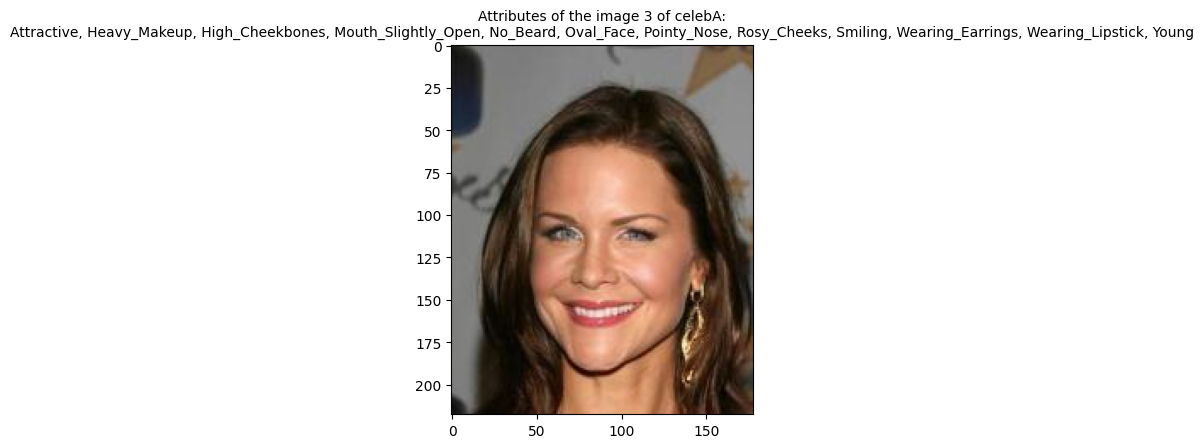

[0.739189624786377, 0.7341614961624146, 0.7308998703956604, 0.7308482527732849, 0.7280566692352295]

[2930, 19171, 8908, 4177, 18946]


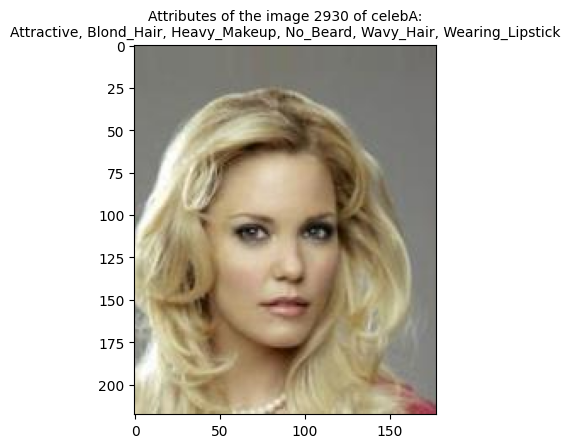

In [80]:
id_query = 3
show_celeb_image(id_query)
query_emb = image_embeddings[id_query]

new_attributes = ["-Smiling", "+Blond_Hair"]

res_ind, score = CH_mixed_cond_retrieval(
    query_img_emb=query_emb,
    id_query=id_query,
    database_embeddings=image_embeddings,
    attributes=new_attributes,
    ordered_attributes=ordered_attributes, 
    model_head=model_head,
    top_k=5,
    device="cuda",
    N=810,
    beta = 0.07
)


print(score)
print()
print(res_ind)

show_celeb_image(res_ind[0])